## Exploratory Data Analysis

### 0. Data Import and Summary

In [1]:
import pandas as pd

data=pd.read_csv('../data/processed/cleaned_dataset.csv')

In [2]:
data.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month,crash_datetime,crash_year,crash_day_name,any_injury
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,0.0,0.0,3.0,13,7,7,2023-07-29 13:00:00,2023,Saturday,0
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,0.0,0.0,2.0,0,1,8,2023-08-13 00:11:00,2023,Sunday,0
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,0.0,0.0,3.0,10,5,12,2021-12-09 10:30:00,2021,Thursday,0
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,5.0,0.0,0.0,19,4,8,2023-08-09 19:55:00,2023,Wednesday,1
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,0.0,0.0,3.0,14,7,8,2023-08-19 14:55:00,2023,Saturday,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209275 entries, 0 to 209274
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209275 non-null  object 
 1   traffic_control_device         209275 non-null  object 
 2   weather_condition              209275 non-null  object 
 3   lighting_condition             209275 non-null  object 
 4   first_crash_type               209275 non-null  object 
 5   trafficway_type                209275 non-null  object 
 6   alignment                      209275 non-null  object 
 7   roadway_surface_cond           209275 non-null  object 
 8   road_defect                    209275 non-null  object 
 9   crash_type                     209275 non-null  object 
 10  intersection_related_i         209275 non-null  object 
 11  damage                         209275 non-null  object 
 12  prim_contributory_cause       

### 1. Accident Frequency and Severity by Weather Type

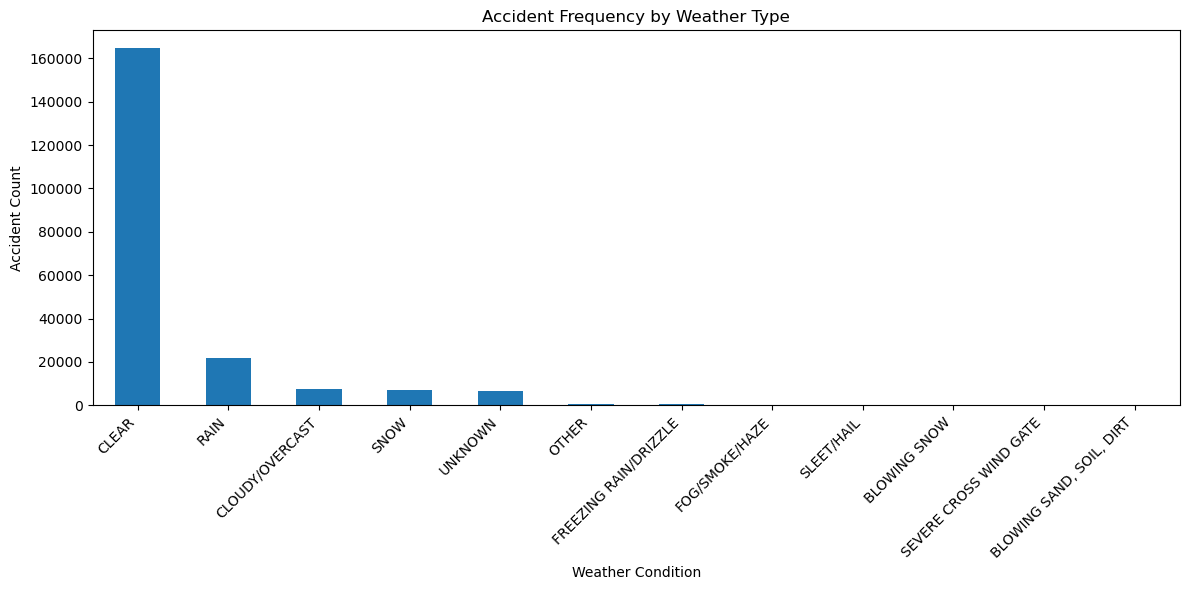

In [4]:
import matplotlib.pyplot as plt

weather_counts = data["weather_condition"].value_counts()

plt.figure(figsize=(12, 6))
weather_counts.plot(kind="bar")
plt.title("Accident Frequency by Weather Type")
plt.xlabel("Weather Condition")
plt.ylabel("Accident Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The bar chart shows that most crashes occur under CLEAR weather. However, this is likely driven by exposure: clear-weather conditions occur much more frequently than rain/snow. Therefore, counts alone cannot indicate risk. A fair comparison requires normalizing by the baseline frequency of each weather condition (i.e., crash rate per unit exposure).

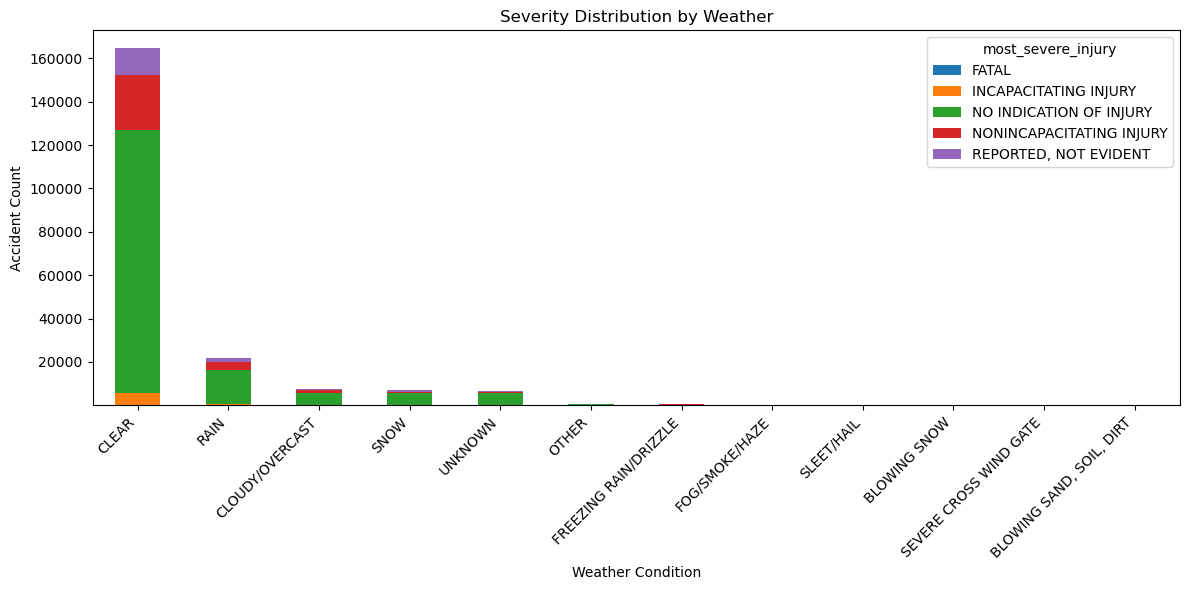

In [5]:
severity_by_weather = (
    pd.crosstab(data["weather_condition"], data["most_severe_injury"])
    .loc[weather_counts.index]
)

severity_by_weather.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Severity Distribution by Weather")
plt.xlabel("Weather Condition")
plt.ylabel("Accident Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Because the weather categories are highly imbalanced, most weather types other than CLEAR, RAIN, CLOUDY/OVERCAST, and SNOW contain very few crash records. Such small sample sizes can yield unstable proportion estimates and make the visualization sensitive to random fluctuation, reducing representativeness. Therefore, for clearer and more reliable comparison, we focus on the top four weather conditions by crash count and plot 2×2 pie charts of the injury-severity distribution for these categories.

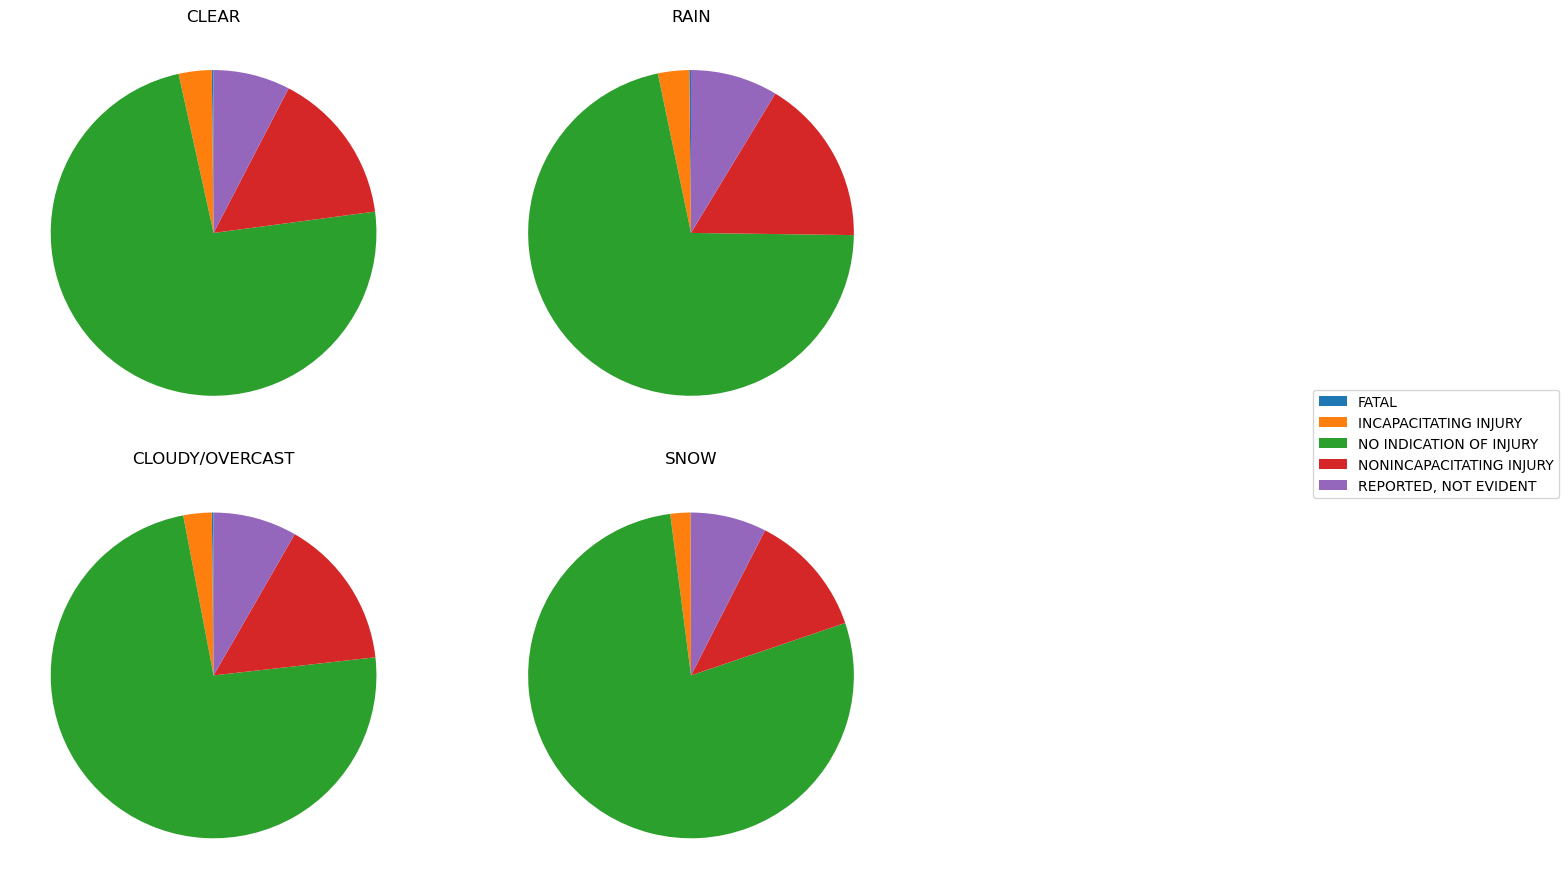

In [6]:
top4_weather = data["weather_condition"].value_counts().head(4).index.tolist()

severity_levels = sorted(data["most_severe_injury"].dropna().unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

handles_ref = None

for ax, w in zip(axes, top4_weather):
    s = data.loc[data["weather_condition"] == w, "most_severe_injury"].value_counts()
    s = s.reindex(severity_levels).fillna(0)

    wedges, _ = ax.pie(s.values, startangle=90, labels=None)
    ax.set_title(w)

    if handles_ref is None:
        handles_ref = wedges

fig.legend(handles_ref, severity_levels, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

From the pie charts, the injury-severity distributions under the four main weather conditions (CLEAR, RAIN, CLOUDY/OVERCAST, SNOW) appear similar. To validate this observation, we performed a chi-square test of independence on the contingency table and reported Cramér’s V as an effect size.

In [7]:
from scipy.stats import chi2_contingency
import numpy as np

top4 = data["weather_condition"].value_counts().head(4).index
df4 = data[data["weather_condition"].isin(top4)]

ct = pd.crosstab(df4["weather_condition"], df4["most_severe_injury"])

chi2, p, dof, expected = chi2_contingency(ct)

n = ct.to_numpy().sum()
r, c = ct.shape
cramers_v = np.sqrt((chi2 / n) / (min(r - 1, c - 1)))

std_resid = (ct - expected) / np.sqrt(expected)

print("Contingency table (counts):\n", ct, "\n")
print(f"Chi-square = {chi2:.3f}, dof = {dof}, p-value = {p:.6g}")
print(f"Cramér's V = {cramers_v:.4f}")

print("\nLargest absolute standardized residuals (top 10):")
print(std_resid.abs().stack().sort_values(ascending=False).head(10))

Contingency table (counts):
 most_severe_injury  FATAL  INCAPACITATING INJURY  NO INDICATION OF INJURY  \
weather_condition                                                           
CLEAR                 290                   5392                   121268   
CLOUDY/OVERCAST        13                    212                     5558   
RAIN                   36                    672                    15522   
SNOW                    3                    137                     5370   

most_severe_injury  NONINCAPACITATING INJURY  REPORTED, NOT EVIDENT  
weather_condition                                                    
CLEAR                                  25170                  12553  
CLOUDY/OVERCAST                         1124                    625  
RAIN                                    3592                   1880  
SNOW                                     843                    516   

Chi-square = 171.675, dof = 12, p-value = 2.16894e-30
Cramér's V = 0.0169

Largest abs

**Conclusion:**

We were surprised to find that weather appears to have little impact on crash severity in our data. Since a large share of crashes occur under CLEAR conditions, this suggests that public-safety efforts should not focus only on extreme weather: maintaining strong preparedness and rapid response during normal, clear-weather periods is equally important for reducing severe outcomes.

### 2. Accident Frequency and Severity by Traffic Control Device Type

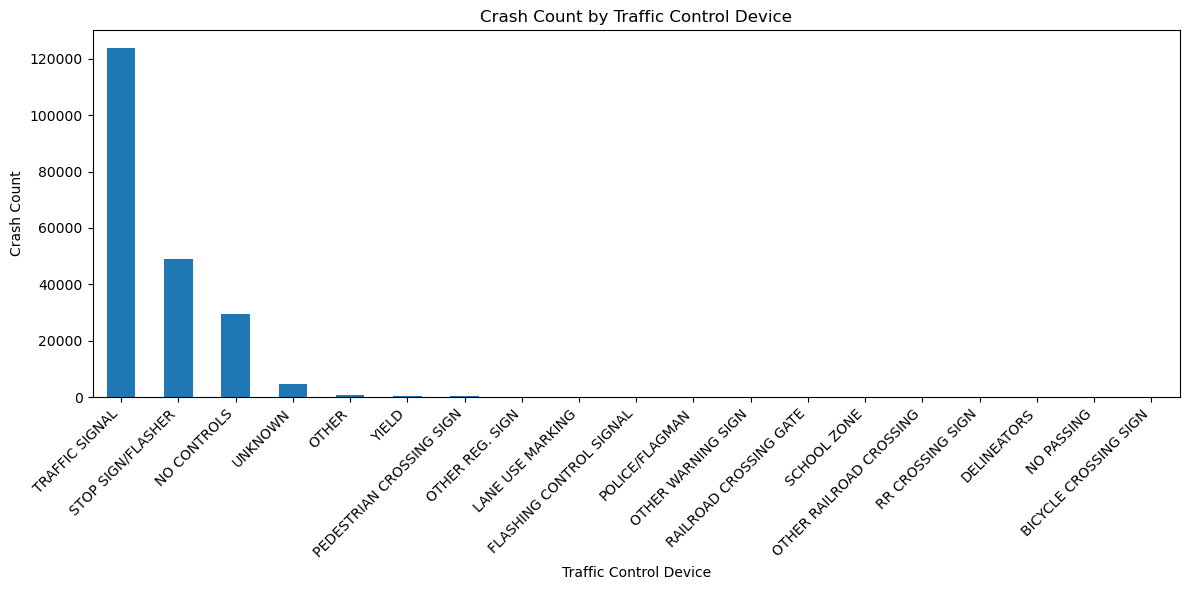

In [8]:
counts = data["traffic_control_device"].value_counts()

plt.figure(figsize=(12, 6))
counts.plot(kind="bar")
plt.title("Crash Count by Traffic Control Device")
plt.xlabel("Traffic Control Device")
plt.ylabel("Crash Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

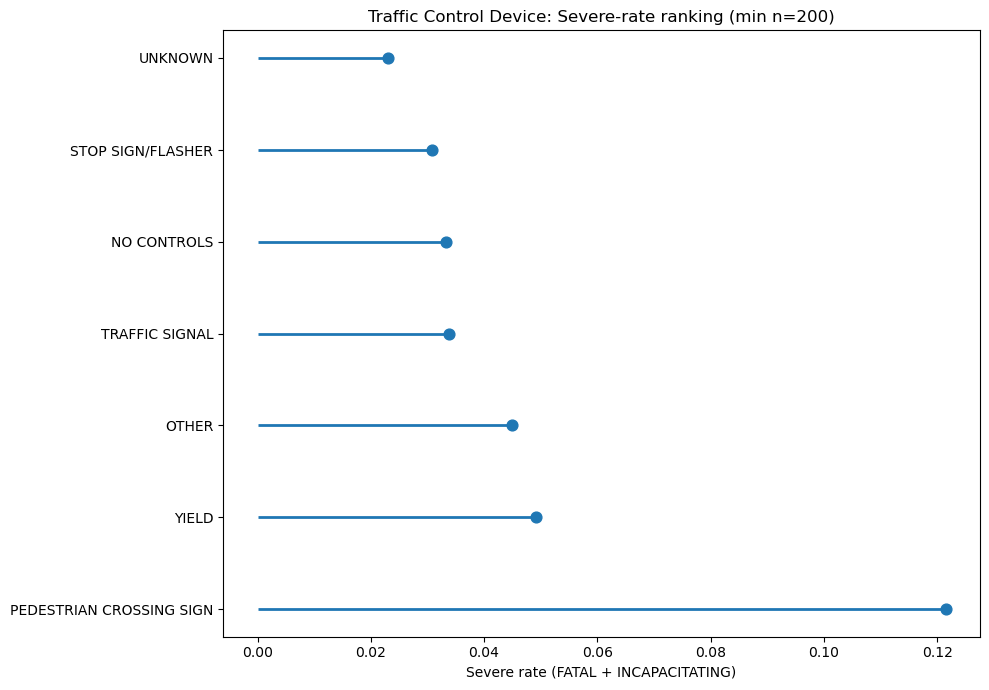

In [9]:
severe_set = {"FATAL", "INCAPACITATING INJURY"}
df = data.copy()
df["is_severe"] = df["most_severe_injury"].isin(severe_set)

g = df.groupby("traffic_control_device").agg(
    n=("is_severe", "size"),
    severe=("is_severe", "sum")
)
g["severe_rate"] = g["severe"] / g["n"]

g = g[g["n"] >= 200].sort_values("severe_rate", ascending=False)

plt.figure(figsize=(10, 7))
y = np.arange(len(g))
plt.hlines(y, 0, g["severe_rate"], linewidth=2)
plt.scatter(g["severe_rate"], y, s=60)
plt.yticks(y, g.index)
plt.xlabel("Severe rate (FATAL + INCAPACITATING)")
plt.title("Traffic Control Device: Severe-rate ranking (min n=200)")
plt.tight_layout()
plt.show()

About 30k crashes occurred in locations labeled NO CONTROLS, indicating that a substantial share of crashes happen outside signalized or otherwise controlled intersections. Note that “NO CONTROLS” simply means no traffic control device was recorded, not necessarily that a control device is missing or required. In addition, the severe-outcome rate (FATAL + INCAPACITATING) appears broadly similar across most device types, suggesting no clear association between crash severity and the presence/type of traffic signal in this dataset.

In [10]:
print(data.columns)

Index(['crash_date', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type',
       'intersection_related_i', 'damage', 'prim_contributory_cause',
       'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour',
       'crash_day_of_week', 'crash_month', 'crash_datetime', 'crash_year',
       'crash_day_name', 'any_injury'],
      dtype='object')


In [11]:
data.info(verbose=True, max_cols=None, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209275 entries, 0 to 209274
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209275 non-null  object 
 1   traffic_control_device         209275 non-null  object 
 2   weather_condition              209275 non-null  object 
 3   lighting_condition             209275 non-null  object 
 4   first_crash_type               209275 non-null  object 
 5   trafficway_type                209275 non-null  object 
 6   alignment                      209275 non-null  object 
 7   roadway_surface_cond           209275 non-null  object 
 8   road_defect                    209275 non-null  object 
 9   crash_type                     209275 non-null  object 
 10  intersection_related_i         209275 non-null  object 
 11  damage                         209275 non-null  object 
 12  prim_contributory_cause       

# 3 Time-of-day vs accident count

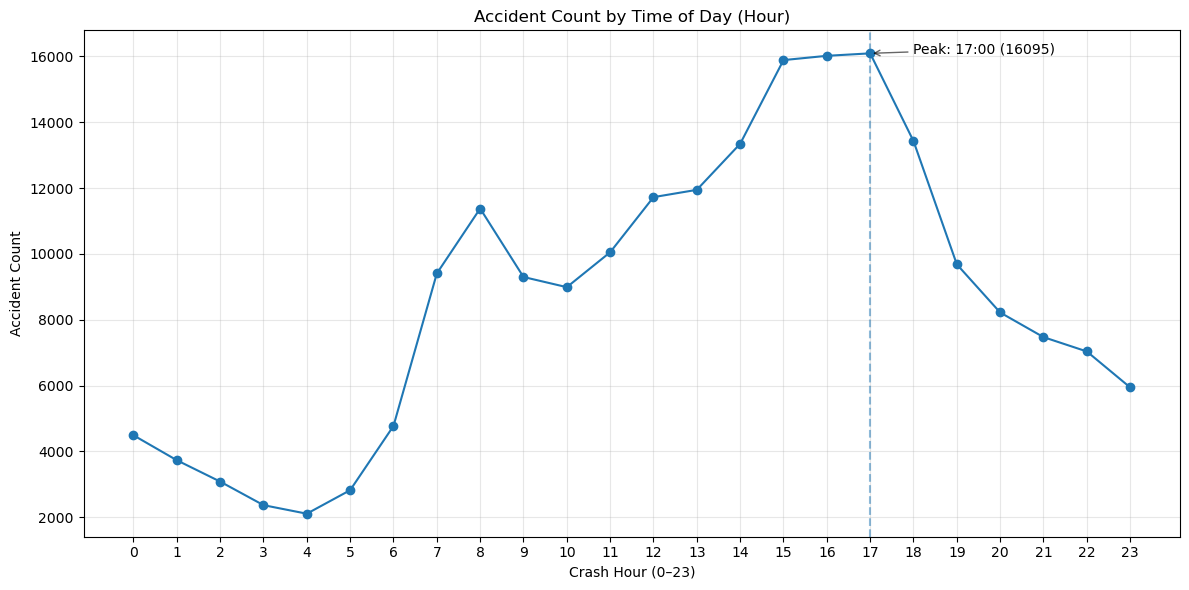

In [12]:
hour_counts = data["crash_hour"].value_counts().sort_index()

peak_hour = int(hour_counts.idxmax())
peak_count = int(hour_counts.max())

plt.figure(figsize=(12, 6))
plt.plot(hour_counts.index, hour_counts.values, marker="o")
plt.title("Accident Count by Time of Day (Hour)")
plt.xlabel("Crash Hour (0–23)")
plt.ylabel("Accident Count")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.axvline(peak_hour, linestyle="--", alpha=0.5)
plt.annotate(
    f"Peak: {peak_hour}:00 ({peak_count})",
    xy=(peak_hour, peak_count),
    xytext=(peak_hour + 1, peak_count),
    arrowprops=dict(arrowstyle="->", alpha=0.6)
)

plt.tight_layout()
plt.show()

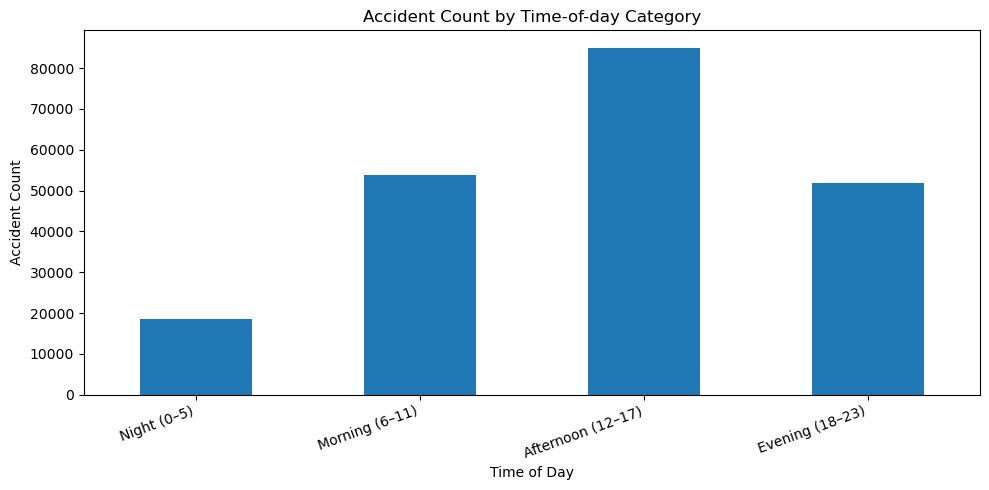

In [13]:
bins = [-0.1, 5, 11, 17, 23]
labels = ["Night (0–5)", "Morning (6–11)", "Afternoon (12–17)", "Evening (18–23)"]

tod_counts = (
    pd.cut(data["crash_hour"], bins=bins, labels=labels)
      .value_counts()
      .reindex(labels)
)

plt.figure(figsize=(10, 5))
tod_counts.plot(kind="bar")
plt.title("Accident Count by Time-of-day Category")
plt.xlabel("Time of Day")
plt.ylabel("Accident Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Hourly accident statistics show that accidents are lowest in the early morning hours (0-5 AM) and rise rapidly after dawn.

The number of accidents peaks at 5:00 PM (approximately 16,095), coinciding with typical evening rush hour.

Accident numbers remain high between 3:00 PM and 5:00 PM, gradually decreasing after 6:00 PM.

The afternoon (12-5 PM) sees the highest number of accidents, approximately 85,000, accounting for the largest proportion of all accidents. This further illustrates that accidents are more likely to occur during periods of higher traffic density.

# 4 hour × weather heatmap

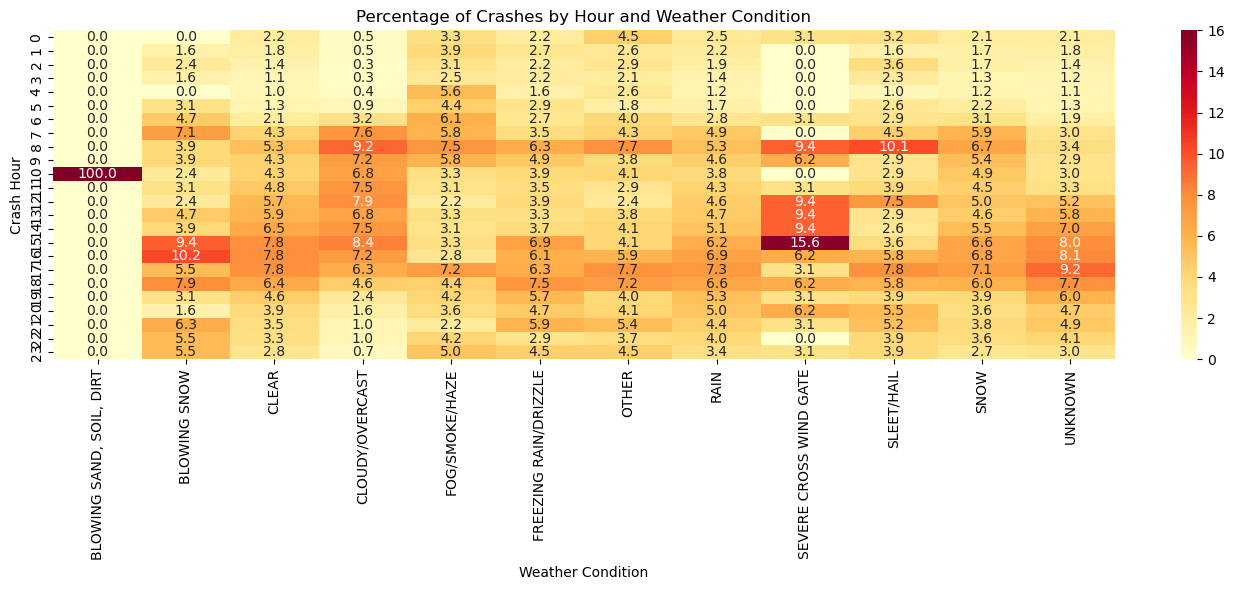

In [14]:
import seaborn as sns
heatmap_data = pd.crosstab(
    data["crash_hour"],
    data["weather_condition"]
)

heatmap_percent = heatmap_data.div(heatmap_data.sum(axis=0), axis=1) * 100

plt.figure(figsize=(14,6))


sns.heatmap(
    heatmap_percent,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    vmin=0,
    vmax=16
)

plt.title("Percentage of Crashes by Hour and Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Crash Hour")

plt.tight_layout()
plt.show()

Under most weather conditions, the peak time for accidents remains concentrated in the afternoon and evening (3 PM–6 PM).

Even under different weather conditions (such as rain, cloudy, and snow), the temporal distribution pattern of accidents remains similar.

This indicates that time factors (traffic flow) may have a more direct impact on the timing of accidents than the weather itself.

Furthermore, some weather conditions show a higher proportion of accidents during specific time periods, for example:
Severe cross winds have a higher proportion in the afternoon;
Cloudy/overcast conditions have a higher proportion of accidents during morning and evening commutes.

However, overall, these differences do not change the general trend that accidents are mainly concentrated during peak commuting hours.

# 5 Seasonal Pattern

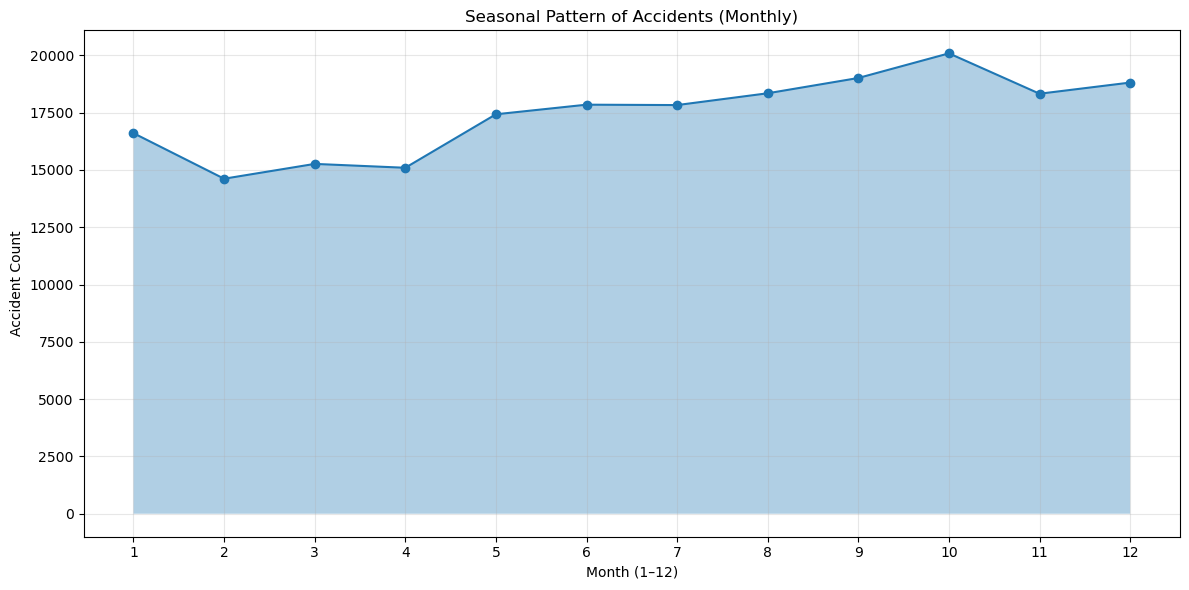

In [15]:
month_counts = data["crash_month"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.fill_between(month_counts.index, month_counts.values, alpha=0.35)
plt.plot(month_counts.index, month_counts.values, marker="o")

plt.title("Seasonal Pattern of Accidents (Monthly)")
plt.xlabel("Month (1–12)")
plt.ylabel("Accident Count")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The monthly accident distribution reveals a seasonal trend in traffic accidents throughout the year.

Overall, the number of accidents is relatively low at the beginning of the year (January–April), with February being the lowest point at approximately 14,500. The number then gradually increases from May, reaching its annual peak in October (approximately 20,000 accidents).

From June to October, the number of accidents remains consistently high, indicating that accidents occur more frequently during the summer and autumn. In November and December, the number of accidents decreases slightly but remains higher than at the beginning of the year.

This trend may be related to factors such as increased traffic activity, higher travel frequency, and weather changes. For example, people travel more during the summer and autumn, thus increasing the likelihood of accidents.

In general, the number of accidents follows a seasonal pattern of gradually increasing from winter to autumn, followed by a slight decrease.